In [20]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import dill
import duckdb

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, RAW_DIR
from src.analysis.metrics import (
    ERA_2004,
    ERA_2016,
    EVENT_COLS,
    build_match_team,
    build_season_metrics
)
from src.analysis.possession import (
    _possession_stats_base,
    _possession_stats_progression,
    _possession_stats_time,
    _possession_directness_ratio,
    _possession_movement_events,
    add_possession_opponent,
    _possession_locations,
    _possession_stats_outcome,
    _possession_stats_pressure
)
from src.analysis.viz import (
    plot_entry_rates,
    plot_possession_duration_by_team,
    plot_possession_progression_scatter,
    plot_possession_start_end_heatmaps,
    plot_pressure_directness_scatter,
)

dill.load_session('../saves/notebook_env.db')

## Possession analysis

We want to see whether the possession was structured vs. chaotic using metrics, such as `duration`, `event_count`, `pass_count`. This helps us understand:

1. How long can the team sustain control?
2. Are possession deliberate or rushed?
3. Does the team recycle possession or attack immediately?

This should provide insight to whether or not the early 2000s premier league fit the stereotype that it had shorter possession, fewer actions, more transitions and quicker vertical attacks. Some other questions to consider:

- How efficiently does the team move upfield?
- Is progression gradual or explosive?
- Does buildup happen through controlled advancement?
- Can the team maintain possession under pressure?
- How does pressure affect possession length?
- Does the team break pressure structurally?
- Which possessions create danger?
- Are dangerous possessions long or short?
- Does the team create chances through structure or transition?


In [21]:
temp_possessions = _possession_stats_base(match_df)
base_possessions = add_possession_opponent(temp_possessions, match_df)

time_control = _possession_stats_time(match_df)
progression = _possession_stats_progression(match_df)
pressure = _possession_stats_pressure(match_df)
outcome = _possession_stats_outcome(match_df)

merge_cols = ["match_id", "period", "possession_id", "possession_team"]
possession_summary = (
    base_possessions
    .merge(time_control, on=merge_cols, how="left")
    .merge(progression, on=merge_cols, how="left")
    .merge(pressure, on=merge_cols, how="left")
    .merge(outcome, on=merge_cols, how="left")
)

possession_summary.to_csv(PROCESSED_DIR / "possession_summary.csv", index=False)

The progression metrics that I gathered, detailed in the columns are:

### Identity
- `match_id`: StatsBomb match id
- `period`: Match period: 1 first half, 2 second half, etc.
- `possession_id`: StatsBomb possession chain id within the match
- `possession_team`: Team that controls the possession chain
- `play_pattern`: How the possession started, e.g. Regular Play, From Throw In, From Corner
- `opponent`: The opposing team in the match

### Time / Control
- `start_minute`: Minute of the first event in the possession
- `start_second`: Second of the first event in the possession
- `end_minute`: Minute of the final event in the possession
- `end_second`: Second of the final event in the possession
- `start_time`: Possession start time in seconds from period clock, calculated as minute * 60 + second
- `end_time`: Possession end time in seconds from period clock, calculated as minute * 60 + second
- `clock_duration`: Elapsed clock time of the possession in seconds
- `action_duration`: Sum of StatsBomb event duration values within the possession
- `avg_event_duration`: Average event duration within the possession
- `event_count`: Total number of events in the possession chain
- `pass_count`: Number of Pass events by the possession team
- `carry_count`: Number of Carry events by the possession team
- `touch_count`: pass_count + carry_count; rough proxy for controlled ball actions

### Tempo / Deliberateness
- `events_per_second`: Event density, calculated as event_count divided by clock_duration
- `passes_per_second`: Pass tempo, calculated as pass_count divided by clock_duration
- `directness_ratio`: Net x progression divided by total pass/carry distance. Near 1 means direct forward play, near 0 means recycling, and negative means backward movement

### Progression
- `start_x`: X coordinate of the possession team’s first on-ball location
- `start_y`: Y coordinate of the possession team’s first on-ball location
- `end_x`: X coordinate of the possession team’s final on-ball/end location
- `end_y`: Y coordinate of the possession team’s final on-ball/end location
- `net_x_progression`: end_x - start_x; how far upfield the possession ended relative to where it began
- `total_x_progression`: Sum of all positive x movement from possession-team passes and carries
- `progressive_distance`: Sum of large positive x movements, currently movements with x gain >= 10
- `max_x_reached`: Furthest x coordinate reached during the possession
- `final_third_entry`: True if the possession reached x >= 80
- `box_entry`: True if the possession reached the box area, defined as x >= 102 and 18 <= y <= 62

### Pressure
- `pressure_event_count`: Number of explicit opponent Pressure events during the possession
- `under_pressure_count`: Number of possession-team events marked under_pressure
- `pressure_rate`: under_pressure_count divided by possession-team event count
- `pressured_pass_count`: Number of possession-team passes made under pressure
- `pressured_pass_completion`: Completion rate of possession-team passes made under pressure
- `counterpress_faced`: Number of opponent events marked counterpress during the possession

### Outcome / Danger
- `shot_count`: Number of shots by the possession team in the possession
- `xg_created`: Sum of shot_statsbomb_xg from possession-team shots
- `key_pass_count`: Number of shot assists or goal assists in the possession
- `turnover_type`: Label inferred from the final possession-team event, e.g. Pass - Incomplete, Shot - Saved, Out
- `ends_with_shot`: True if the final possession-team event was a shot
- `ends_in_final_third`: True if the possession team’s final location was in the final third
- `ends_in_box`: True if the possession team’s final location was in the box


### Visuals

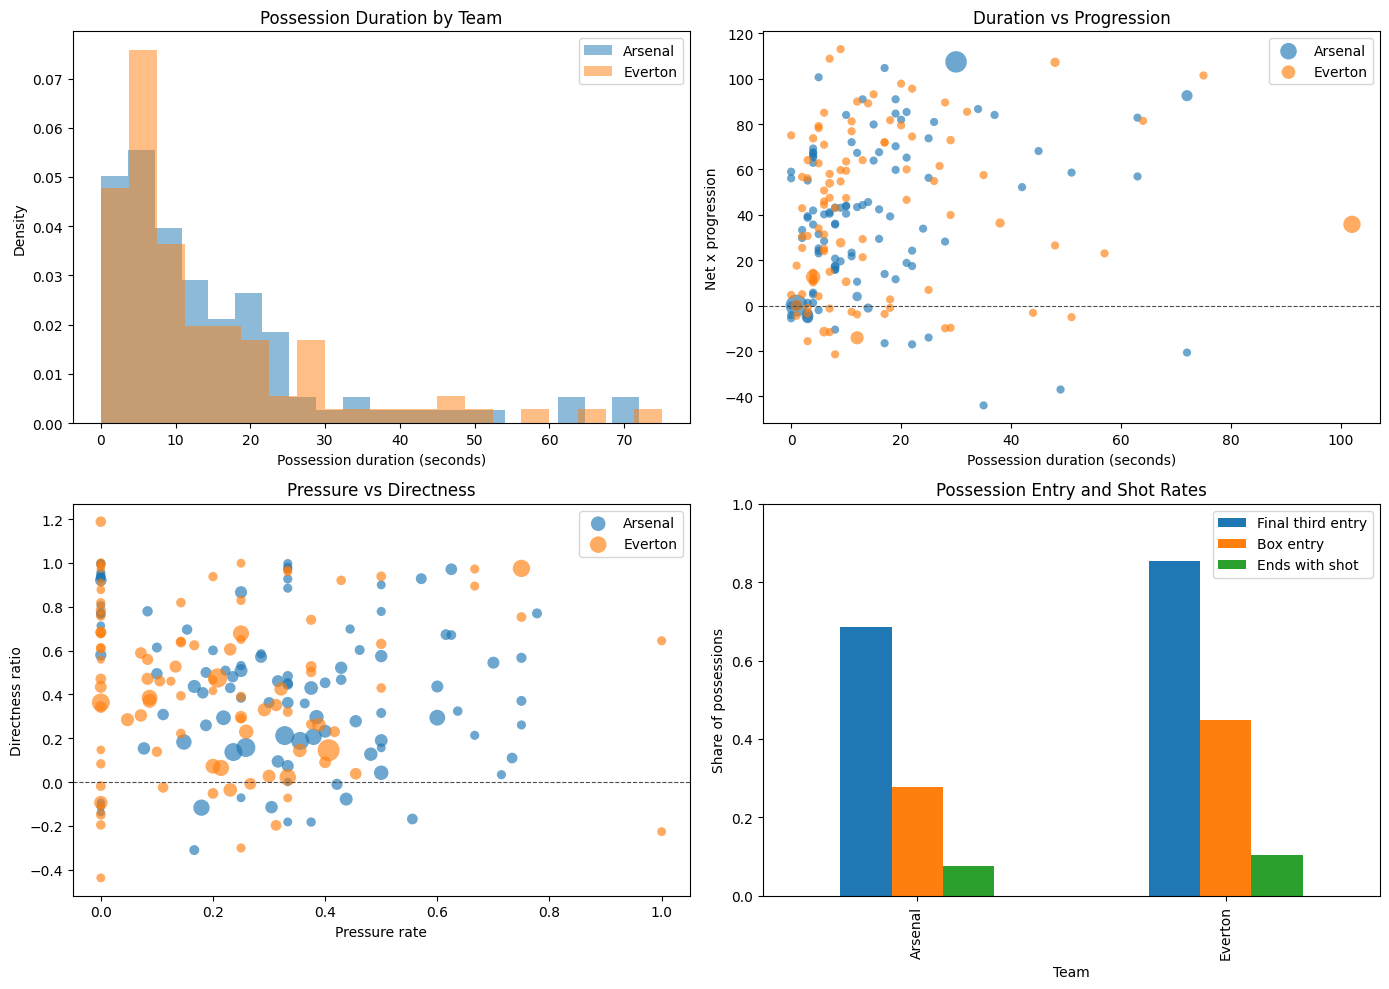

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_possession_duration_by_team(possession_summary, ax=axes[0, 0])
plot_possession_progression_scatter(possession_summary, ax=axes[0, 1])
plot_pressure_directness_scatter(possession_summary, ax=axes[1, 0])
plot_entry_rates(possession_summary, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [23]:
danger_cols = [
    "possession_team",
    "possession_id",
    "clock_duration",
    "pass_count",
    "net_x_progression",
    "directness_ratio",
    "pressure_rate",
    "xg_created",
    "box_entry",
    "turnover_type",
]

possession_summary.sort_values(
    ["xg_created", "box_entry", "net_x_progression"],
    ascending=[False, True, True],
)[danger_cols].head(10)

,possession_team,possession_id,clock_duration,pass_count,net_x_progression,directness_ratio,pressure_rate,xg_created,box_entry,turnover_type
73,Arsenal,74,1,0,0.0,NaN,0.000000,0.783500,True,Shot - Goal
131,Arsenal,131,30,6,107.4,0.428936,0.375000,0.747578,True,Shot - Goal
15,Everton,16,102,9,35.8,0.145135,0.406250,0.440552,True,Foul Won
158,Everton,158,4,1,12.6,-0.301131,0.250000,0.266854,True,Shot - Off T
181,Everton,181,12,6,-14.2,-0.197794,0.312500,0.200138,True,Shot - Goal
117,Arsenal,117,3,1,-4.8,-0.110900,0.000000,0.132282,True,Shot - Off T
60,Everton,61,1,0,0.0,NaN,0.000000,0.118119,False,Shot - Blocked
78,Arsenal,79,72,21,92.5,0.211871,0.327869,0.106324,True,Shot - Off T
34,Arsenal,35,1,0,0.0,NaN,0.000000,0.085029,False,Shot - Off T
44,Arsenal,45,3,1,-5.5,-0.182241,0.333333,0.084167,True,Shot - Off T


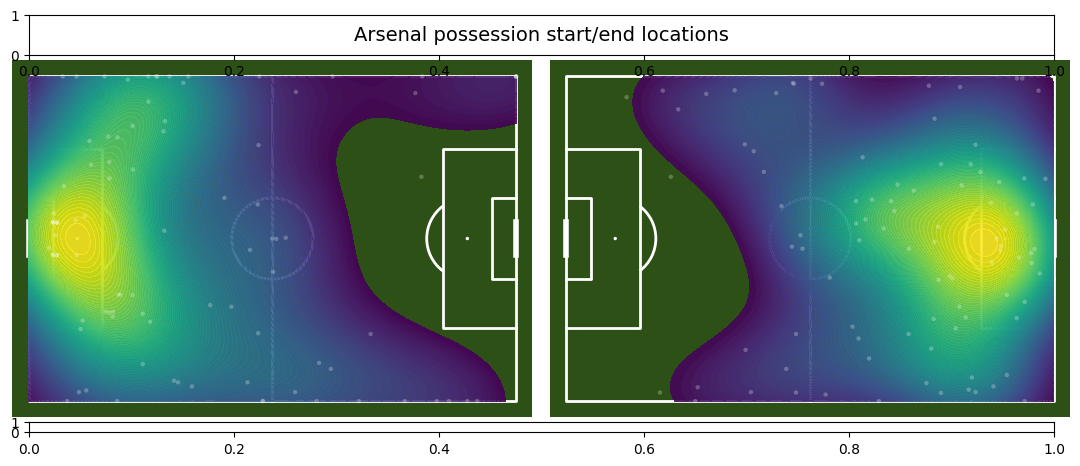

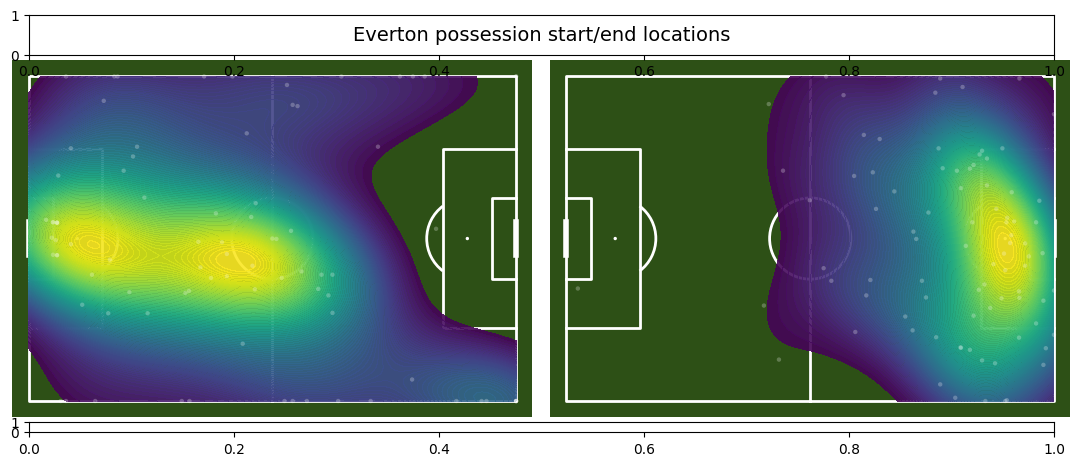

In [24]:
from IPython.display import display

for team in possession_summary["possession_team"].dropna().unique():

    fig = plot_possession_start_end_heatmaps(
        possession_summary,
        team=team,
        min_duration=3,
    )

    # display(fig)
    plt.show()

In [25]:
dill.dump_session('../saves/notebook_env.db') 